In [1]:
import os
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import tqdm

In [16]:
df = pd.read_csv('collar_preds_df.csv')

In [19]:
df.head(1)

,dir,session,vid,color type,color pair,tracked,error,lever,mag,event id,fiber pho,coop thresh,animal id,cohort,visual,vehicle,familiar,useable,single/multi
0,PairedTestingSessions,022125_PairedTesting_TimeOut_DREADD_KM010-KM01...,022125_Cam1_TrNum8_Coop_KM010Y-KM015G_DCZ-SAL,collar,GY,True,0.469372,False,False,False,False,NaN,KM010Y-KM015G,KM,transparent,DCZ,unsure,unuseable,multi


In [45]:
list((locations.shape))

[36441, 5, 2, 2]

In [47]:
df['loc shape'] = df['loc shape'].astype(object)

for index, row in df.iterrows():
    root = '/gpfs/radev/pi/saxena/aj764/' + row['dir'] + '/' + row['session'] + '/'
    if os.path.exists(root + 'Tracking/h5/' + row['vid'] + '.predictions.h5'):
        with h5py.File(root + 'Tracking/h5/' + row['vid'] + '.predictions.h5','r') as f:
            locations = f["tracks"][:].T
    elif os.path.exists(root + 'Tracking_BottomUp/h5/' + row['vid'] + '.predictions.h5'):
        with h5py.File(root + 'Tracking_BottomUp/h5/' + row['vid'] + '.predictions.h5','r') as f:
            locations = f["tracks"][:].T
    else:
        locations = None
        
    if locations is not None:
        df.at[index, 'tracked'] = True
        df.at[index, 'error'] = np.sum(np.isnan(locations)) / np.prod(locations.shape)
        df.at[index, 'loc shape'] = list((locations.shape))
        if not (len(locations.shape) == 4 and locations.shape[2] == 2 and ((locations.shape[1] == 15 and locations.shape[3] == 1) or (locations.shape[1] == 5 and locations.shape[3] == 2))):
            df.at[index, 'wrong shape'] = True
        else:
            df.at[index, 'wrong shape'] = False

In [60]:
df[df['tracked'] & (df['wrong shape'] == True)]
np.unique(df[df['tracked'] & (df['wrong shape'] == True)]['loc shape'])

array([list([383, 5, 2, 1]), list([389, 5, 2, 1]), list([1742, 5, 2, 1]),
       list([1743, 5, 2, 1]), list([6391, 5, 2, 1]),
       list([11685, 5, 2, 1]), list([12558, 5, 2, 1]),
       list([12687, 5, 2, 1]), list([12983, 5, 2, 1]),
       list([13671, 5, 2, 1]), list([14708, 5, 2, 1]),
       list([14960, 5, 2, 1]), list([15679, 5, 2, 1]),
       list([15875, 5, 2, 1]), list([16026, 5, 2, 1]),
       list([16072, 5, 2, 1]), list([16205, 5, 2, 1]),
       list([16216, 5, 2, 1]), list([16369, 5, 2, 1]),
       list([16657, 5, 2, 1]), list([16822, 5, 2, 1]),
       list([17058, 5, 2, 1]), list([17063, 5, 2, 1]),
       list([17117, 5, 2, 1]), list([17258, 5, 2, 1]),
       list([17272, 5, 2, 1]), list([17446, 5, 2, 1]),
       list([17524, 5, 2, 1]), list([17793, 5, 2, 1]),
       list([18250, 5, 2, 1]), list([18295, 5, 2, 1]),
       list([18312, 5, 2, 1]), list([18562, 5, 2, 1]),
       list([18579, 5, 2, 1]), list([18710, 5, 2, 1]),
       list([18731, 5, 2, 1]), list([18743, 5, 2

In [58]:
df[df['tracked'] & (df['wrong shape'] == False)]['color pair']

0      GY
11     GY
17     GY
20     GY
23     GY
       ..
609    GY
612    GY
614    GY
619    GY
620    GY
Name: color pair, Length: 88, dtype: object

In [52]:
df.to_csv('loc_shape_collars_df.csv')

(array([10., 30., 23., 11.,  6.,  0.,  3.,  2.,  2.,  1.]),
 array([0.09827806, 0.13499052, 0.17170299, 0.20841545, 0.24512792,
        0.28184038, 0.31855285, 0.35526531, 0.39197778, 0.42869024,
        0.4654027 ]),
 <BarContainer object of 10 artists>)

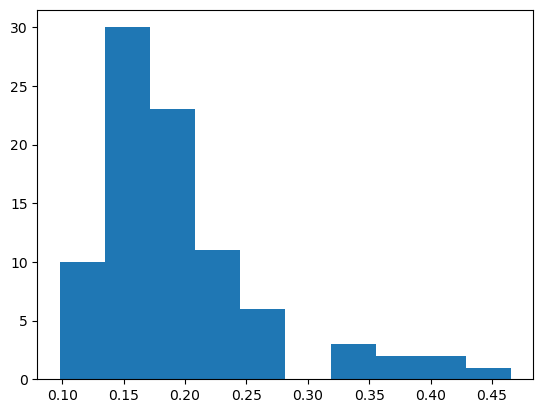

In [64]:
plt.hist(df[df['color pair'] == 'GY']['error'])

In [13]:
no_tracking = []
for root, dirs, files in tqdm.tqdm(os.walk("/gpfs/radev/pi/saxena/aj764/")):
    for file in files:
        if file.endswith(".h5"):
            # print(os.path.join(root, file))
            try:
                with h5py.File(os.path.join(root, file),'r') as f:
                    locations = f["tracks"][:].T
                if not (len(locations.shape) == 4 and locations.shape[2] == 2 and ((locations.shape[1] == 15 and locations.shape[3] == 1) or (locations.shape[1] == 5 and locations.shape[3] == 2))):
                    # print(os.path.join(root, file), locations.shape)
                    no_tracking.append(os.path.join(root, file))
            except Exception as e:
                print(e, os.path.join(root, file))

25724it [09:55,  3.87it/s] 

Unable to synchronously open file (bad object header version number) /gpfs/radev/pi/saxena/aj764/Training_COOPERATION/Tracking/h5/111424_COOPTRAIN_LARGEARENA_NM005R-NM005G_Camera2.predictions.h5


26322it [10:38, 21.87it/s]

"Unable to synchronously open object (object 'tracks' doesn't exist)" /gpfs/radev/pi/saxena/aj764/SLEAP_Model_Testing/Collar-Yellow-Blue/models/260112_231015.multi_class_topdown/best_model.h5
"Unable to synchronously open object (object 'tracks' doesn't exist)" /gpfs/radev/pi/saxena/aj764/SLEAP_Model_Testing/Collar-Yellow-Blue/models/250401_234314.multi_class_topdown/best_model.h5
"Unable to synchronously open object (object 'tracks' doesn't exist)" /gpfs/radev/pi/saxena/aj764/SLEAP_Model_Testing/Collar-Yellow-Blue/models/250713_161547.multi_class_topdown/best_model.h5
"Unable to synchronously open object (object 'tracks' doesn't exist)" /gpfs/radev/pi/saxena/aj764/SLEAP_Model_Testing/Collar-Yellow-Blue/models/250721_133244.multi_class_topdown/best_model.h5


26326it [10:38, 20.57it/s]

...

32006it [16:35, 31.71it/s] 

"Unable to synchronously open object (object 'tracks' doesn't exist)" /gpfs/radev/pi/saxena/aj764/PairedTestingSessions/Nina_Model_Testing/Yellow-Blue/models/250213_173127.multi_class_topdown/best_model.h5
"Unable to synchronously open object (object 'tracks' doesn't exist)" /gpfs/radev/pi/saxena/aj764/PairedTestingSessions/Nina_Model_Testing/Yellow-Blue/models/250213_173127.centroid/best_model.h5
"Unable to synchronously open object (object 'tracks' doesn't exist)" /gpfs/radev/pi/saxena/aj764/PairedTestingSessions/Nina_Model_Testing/Collars/Yellow-Blue/models/250401_200741.multi_class_topdown/best_model.h5


32012it [16:35, 32.31it/s]

"Unable to synchronously open object (object 'tracks' doesn't exist)" /gpfs/radev/pi/saxena/aj764/PairedTestingSessions/Nina_Model_Testing/Collars/Yellow-Blue/models/250401_200741.centroid/best_model.h5


32723it [17:15, 31.60it/s]


In [15]:
len(no_tracking)

1024

In [14]:
print(no_tracking)

['/gpfs/radev/pi/saxena/aj764/Training_COOPERATION/111924/Tracking_BottomUp/h5/111924_COOPTRAIN_LARGEARENA_NM002B-NM002Y_Camera2.predictions.h5', '/gpfs/radev/pi/saxena/aj764/Training_COOPERATION/111924/Tracking_BottomUp/h5/111924_COOPTRAIN_LARGEARENA_NF018B-NF018Y_Camera3.predictions.h5', '/gpfs/radev/pi/saxena/aj764/Training_COOPERATION/111924/Tracking_BottomUp/h5/111924_COOPTRAIN_LARGEARENA_NF009R-NF009G_Camera4.predictions.h5', '/gpfs/radev/pi/saxena/aj764/Training_COOPERATION/111924/Tracking_BottomUp/h5/111924_COOPTRAIN_LARGEARENA_NM003R-NM003G_Camera2.predictions.h5', '/gpfs/radev/pi/saxena/aj764/Training_COOPERATION/111924/Tracking_BottomUp/h5/111924_COOPTRAIN_LARGEARENA_NF010B-NF010Y_Camera3.predictions.h5', '/gpfs/radev/pi/saxena/aj764/Training_COOPERATION/111924/Tracking_BottomUp/h5/111924_COOPTRAIN_LARGEARENA_NM014B-NM014Y_Camera1.predictions.h5', '/gpfs/radev/pi/saxena/aj764/Training_COOPERATION/111924/Tracking_BottomUp/h5/111924_COOPTRAIN_LARGEARENA_NF019R-NF019G_Camera4.p